# Random Forest — AQI Forecasting

**MSE 546 — AQI Forecasting (Group 2)**  
This notebook implements **Random Forest** for the same regression task as the baseline: predict **daily AQI** given city, pollutants, calendar, and historical AQI.

**Why Random Forest:**
- **Task:** Regression — predict a continuous AQI value (same target as Ridge).
- **Nonlinearity:** Trees capture interactions and thresholds (e.g. "if PM2.5 > X and season == winter then higher AQI") that Ridge cannot.
- **Severe days:** Ridge over-smooths extremes (MAE on Severe ≈ 201); forests often do better on tail events.
- **Same pipeline:** We use the same features, temporal split, log-target training, and evaluation (RMSE, MAE, R², per-category MAE) as in `preprocessing.py` and the baseline.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.metrics import mean_squared_error
import warnings
warnings.filterwarnings('ignore')

from preprocessing import (
    load_and_prepare, impute, build_features,
    get_train_test, get_arrays, evaluate, save_results,
    AQI_LABELS, CUTOFF_DATE,
)

plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

## 1. Load data and split into train / validation / test

Same preprocessing as every other notebook. We add a **temporal validation window** (Oct–Nov 2019) carved from training data — this is used for hyperparameter tuning and model selection without touching the test set.

In [2]:
df = load_and_prepare()
df = impute(df)
df, feature_cols = build_features(df)

# --- temporal splits ---
VAL_CUTOFF = pd.Timestamp('2019-10-01')

full_train_df = df[df['date'] < CUTOFF_DATE].copy().reset_index(drop=True)
test_df       = df[df['date'] >= CUTOFF_DATE].copy().reset_index(drop=True)

train_df = full_train_df[full_train_df['date'] < VAL_CUTOFF].reset_index(drop=True)
val_df   = full_train_df[full_train_df['date'] >= VAL_CUTOFF].reset_index(drop=True)

# arrays for train-sub / val
X_train_sub, X_val, y_train_sub_log, y_val_raw, y_val_log = get_arrays(train_df, val_df, feature_cols)

# arrays for full-train / test (used after tuning)
X_train_full, X_test, y_train_full_log, y_test_raw, y_test_log = get_arrays(full_train_df, test_df, feature_cols)

print(f'Features: {len(feature_cols)}')
print(f'Train-sub: {X_train_sub.shape[0]:,} | Val: {X_val.shape[0]:,} | Test: {X_test.shape[0]:,}')
print(f'Train dates: ... to {train_df["date"].max().date()}')
print(f'Val dates:   {val_df["date"].min().date()} to {val_df["date"].max().date()}')
print(f'Test dates:  {test_df["date"].min().date()} to {test_df["date"].max().date()}')

Features: 70
Train-sub: 18,431 | Val: 1,319 | Test: 5,100
Train dates: ... to 2019-09-30
Val dates:   2019-10-01 to 2019-11-30
Test dates:  2019-12-01 to 2020-07-01


## 2. Sample weights for severe-day emphasis

AQI follows a heavy right skew — most days are Good/Satisfactory, but **Severe days are the most important to predict accurately.** We compute sample weights so the model pays more attention to extreme events during training.

In [3]:
from preprocessing import AQI_BINS

def make_sample_weights(y_log, bins=AQI_BINS):
    """Higher weight for rarer / more extreme AQI categories."""
    y_raw = np.expm1(y_log)
    cats = pd.cut(pd.Series(y_raw), bins=bins, labels=AQI_LABELS)
    freq = cats.value_counts(normalize=True)
    # inverse-frequency weighting, capped so Severe doesn't dominate entirely
    cat_weight = {c: min(1.0 / max(f, 1e-4), 20.0) for c, f in freq.items()}
    weights = cats.map(cat_weight).values.astype(float)
    # normalise so mean weight ≈ 1
    weights /= weights.mean()
    return weights

# weights for the train-sub (used during tuning)
w_train_sub = make_sample_weights(y_train_sub_log)
# weights for the full training set (used for final model)
w_train_full = make_sample_weights(y_train_full_log)

print('Sample weight by AQI category (train-sub):')
y_raw_sub = np.expm1(y_train_sub_log)
cats = pd.cut(pd.Series(y_raw_sub), bins=AQI_BINS, labels=AQI_LABELS)
for cat in AQI_LABELS:
    mask = (cats == cat).values
    if mask.sum() > 0:
        print(f'  {cat:>14s}: n={mask.sum():>5,}  avg weight={w_train_sub[mask].mean():.2f}')

Sample weight by AQI category (train-sub):
            Good: n=  753  avg weight=3.44
    Satisfactory: n=5,485  avg weight=0.58
        Moderate: n=6,811  avg weight=0.47
            Poor: n=2,184  avg weight=1.45
       Very Poor: n=1,980  avg weight=1.60
          Severe: n=1,218  avg weight=2.60


## 3. Hyperparameter tuning with temporal cross-validation

We use `TimeSeriesSplit` (5 folds) instead of random k-fold to prevent future-data leakage during tuning. `RandomizedSearchCV` searches over tree depth, leaf size, feature fraction, and ensemble size.

In [4]:
param_dist = {
    'n_estimators':    [200, 300, 500],
    'max_depth':       [10, 15, 20, 25, None],
    'min_samples_leaf': [5, 10, 20],
    'max_features':    ['sqrt', 0.3, 0.5],
}

tscv = TimeSeriesSplit(n_splits=5)

search = RandomizedSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_distributions=param_dist,
    n_iter=20,
    cv=tscv,
    scoring='neg_mean_squared_error',
    random_state=42,
    n_jobs=-1,
    verbose=1,
)
search.fit(X_train_sub, y_train_sub_log, sample_weight=w_train_sub)

print(f'\nBest params: {search.best_params_}')
print(f'Best CV RMSE (log scale): {np.sqrt(-search.best_score_):.4f}')

# validate on held-out val set
y_val_pred_log = search.best_estimator_.predict(X_val)
y_val_pred_raw = np.clip(np.expm1(y_val_pred_log), 0, None)
val_rmse = np.sqrt(mean_squared_error(y_val_raw, y_val_pred_raw))
print(f'Validation RMSE (AQI scale): {val_rmse:.2f}')
evaluate(y_val_raw, y_val_pred_raw, label='RF tuned (val set)')

Fitting 5 folds for each of 20 candidates, totalling 100 fits

Best params: {'n_estimators': 300, 'min_samples_leaf': 5, 'max_features': 0.5, 'max_depth': 25}
Best CV RMSE (log scale): 0.1931
Validation RMSE (AQI scale): 35.91

──────────────────────────────────────────────────────
  RF tuned (val set)
──────────────────────────────────────────────────────
  RMSE :    35.91
  MAE  :    16.11
  R²   :   0.9385
  MAE by AQI category:
              Good:    7.78  (n=53)
      Satisfactory:    7.93  (n=452)
          Moderate:   12.30  (n=443)
              Poor:   19.16  (n=191)
         Very Poor:   20.91  (n=111)
            Severe:   84.40  (n=69)


{'label': 'RF tuned (val set)',
 'RMSE': 35.91431262941754,
 'MAE': 16.109943546615586,
 'R2': 0.9385480524010433,
 'MAE_Good': 7.77504276858449,
 'MAE_Satisfactory': 7.930009489845438,
 'MAE_Moderate': 12.299880335335038,
 'MAE_Poor': 19.15850734747964,
 'MAE_Very Poor': 20.90612676469242,
 'MAE_Severe': 84.4039423048979}

## 4. Retrain best config on full training data and evaluate on test set

Now that hyperparameters are selected via temporal CV + validation, we retrain on **all data before the test cutoff** and evaluate on the held-out test period.

In [5]:
best_params = search.best_params_
rf_final = RandomForestRegressor(
    **best_params,
    random_state=42,
    n_jobs=-1,
)
rf_final.fit(X_train_full, y_train_full_log, sample_weight=w_train_full)

y_pred_log_rf = rf_final.predict(X_test)
y_pred_raw_rf = np.clip(np.expm1(y_pred_log_rf), 0, None)

result_rf = evaluate(y_test_raw, y_pred_raw_rf, label='Random Forest')
save_results(result_rf, 'random_forest')


──────────────────────────────────────────────────────
  Random Forest
──────────────────────────────────────────────────────
  RMSE :    22.47
  MAE  :    11.26
  R²   :   0.9382
  MAE by AQI category:
              Good:    6.01  (n=535)
      Satisfactory:    6.96  (n=2,116)
          Moderate:   12.69  (n=1,746)
              Poor:   22.38  (n=406)
         Very Poor:   15.16  (n=236)
            Severe:   76.19  (n=61)
Saved → results\random_forest_metrics.json


## 5. Feature importance

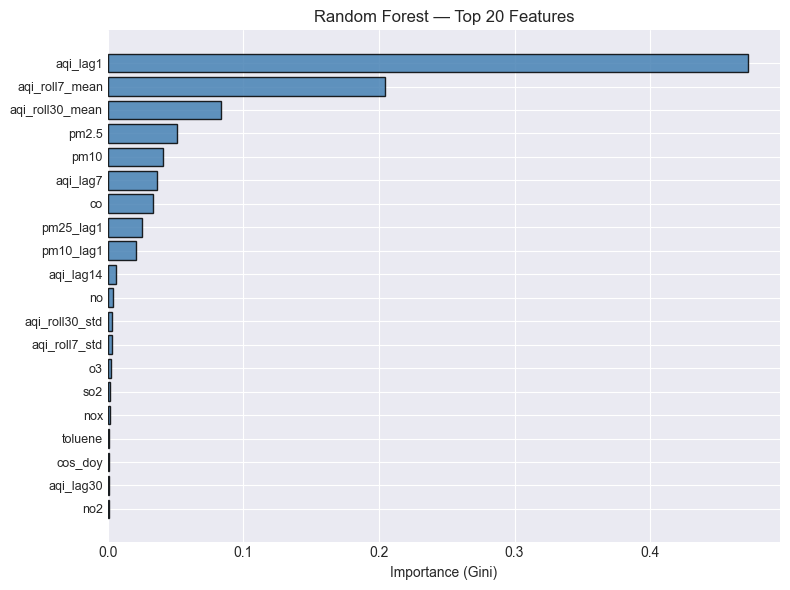

In [6]:
importances = rf_final.feature_importances_
top_n = 20
order = np.argsort(importances)[-top_n:]

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(range(top_n), importances[order], color='steelblue', edgecolor='black', alpha=0.85)
ax.set_yticks(range(top_n))
ax.set_yticklabels([feature_cols[i] for i in order], fontsize=9)
ax.set_xlabel('Importance (Gini)')
ax.set_title('Random Forest — Top 20 Features')
plt.tight_layout()
plt.show()

## 6. Residual diagnostics

Visualise prediction errors to identify systematic failure patterns by city, AQI range, and season.

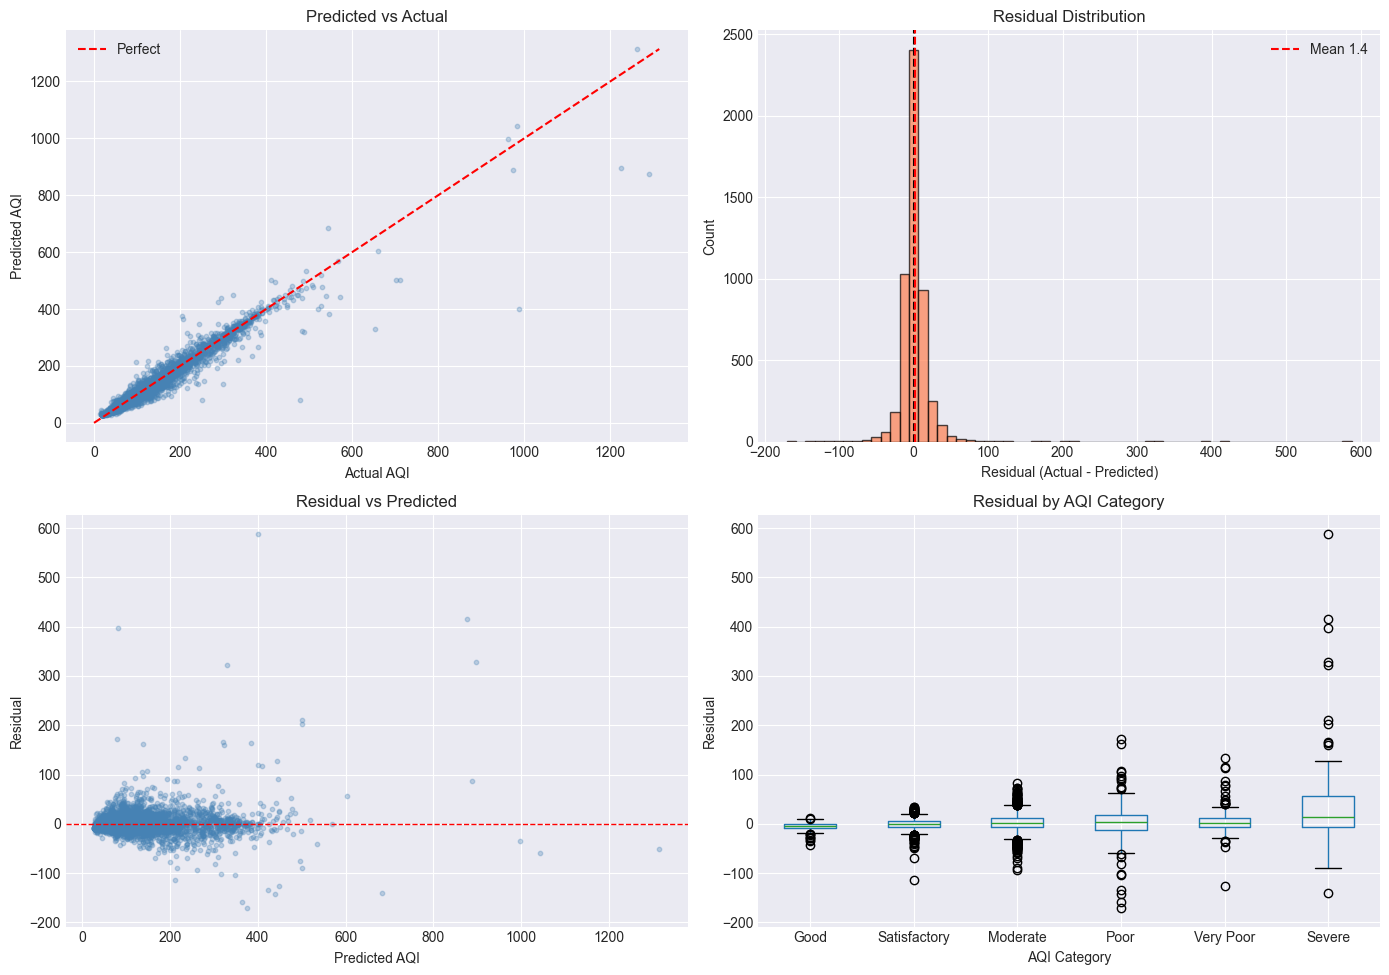

In [7]:
residuals = y_test_raw - y_pred_raw_rf

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Predicted vs actual scatter
ax = axes[0, 0]
ax.scatter(y_test_raw, y_pred_raw_rf, alpha=0.3, s=10, color='steelblue')
lim = max(y_test_raw.max(), y_pred_raw_rf.max())
ax.plot([0, lim], [0, lim], 'r--', lw=1.5, label='Perfect')
ax.set(xlabel='Actual AQI', ylabel='Predicted AQI', title='Predicted vs Actual')
ax.legend()

# 2. Residual distribution
ax = axes[0, 1]
ax.hist(residuals, bins=60, color='coral', edgecolor='black', alpha=0.7)
ax.axvline(0, color='black', ls='--', lw=1.5)
ax.axvline(residuals.mean(), color='red', ls='--', label=f'Mean {residuals.mean():.1f}')
ax.set(xlabel='Residual (Actual - Predicted)', ylabel='Count', title='Residual Distribution')
ax.legend()

# 3. Residual vs predicted (heteroscedasticity check)
ax = axes[1, 0]
ax.scatter(y_pred_raw_rf, residuals, alpha=0.3, s=10, color='steelblue')
ax.axhline(0, color='red', ls='--', lw=1)
ax.set(xlabel='Predicted AQI', ylabel='Residual', title='Residual vs Predicted')

# 4. Residual by AQI category
ax = axes[1, 1]
cats = pd.cut(pd.Series(y_test_raw), bins=AQI_BINS, labels=AQI_LABELS)
res_df = pd.DataFrame({'residual': residuals, 'category': cats})
res_df.boxplot(column='residual', by='category', ax=ax)
ax.set(xlabel='AQI Category', ylabel='Residual', title='Residual by AQI Category')
ax.get_figure().suptitle('')

plt.tight_layout()
plt.show()

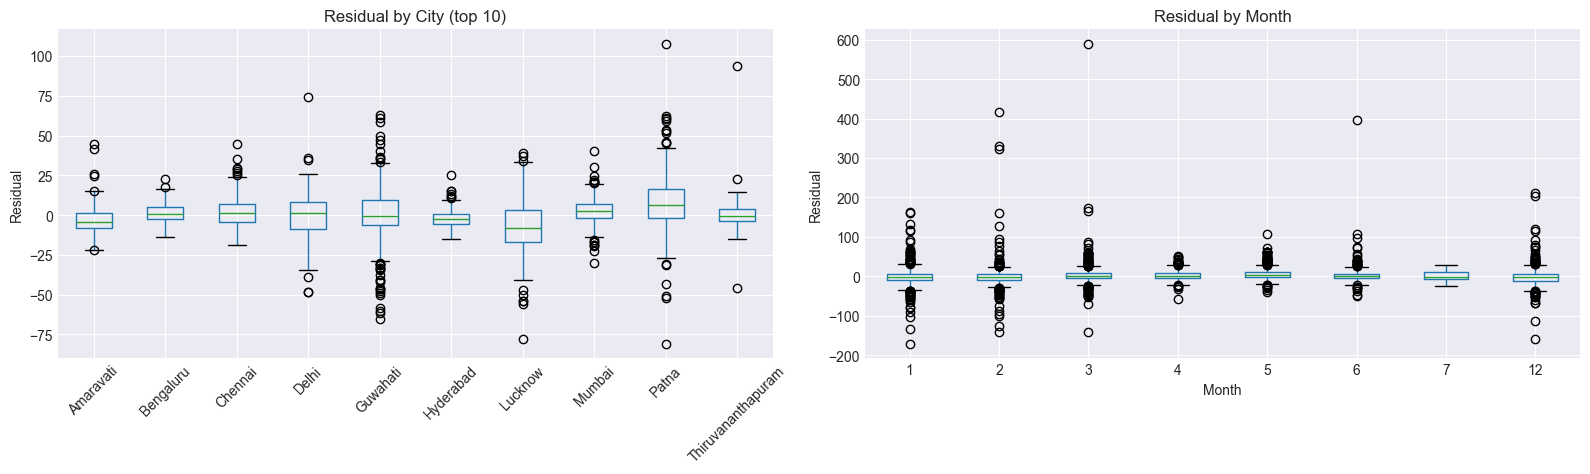

Per-city MAE (top 10 worst):
city
Ahmedabad       45.055904
Brajrajnagar    16.361520
Patna           16.057365
Talcher         14.871799
Lucknow         14.514800
Guwahati        14.503532
Kochi           13.702187
Jorapokhar      13.536377
Gurugram        12.348086
Amritsar        11.963032


In [8]:
# --- Residual by city (top 10 cities by test count) ---
diag_df = test_df[['city', 'date']].copy()
diag_df['residual'] = residuals
diag_df['month'] = diag_df['date'].dt.month

top_cities = diag_df['city'].value_counts().head(10).index
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# by city
ax = axes[0]
diag_df[diag_df['city'].isin(top_cities)].boxplot(
    column='residual', by='city', ax=ax, rot=45
)
ax.set(title='Residual by City (top 10)', xlabel='', ylabel='Residual')
ax.get_figure().suptitle('')

# by month
ax = axes[1]
diag_df.boxplot(column='residual', by='month', ax=ax)
ax.set(title='Residual by Month', xlabel='Month', ylabel='Residual')
ax.get_figure().suptitle('')

plt.tight_layout()
plt.show()

# per-city MAE
city_mae = diag_df.groupby('city')['residual'].apply(lambda x: np.abs(x).mean()).sort_values(ascending=False)
print('Per-city MAE (top 10 worst):')
print(city_mae.head(10).to_string())

## 7. Time-series overlay — predictions vs actuals for sample cities

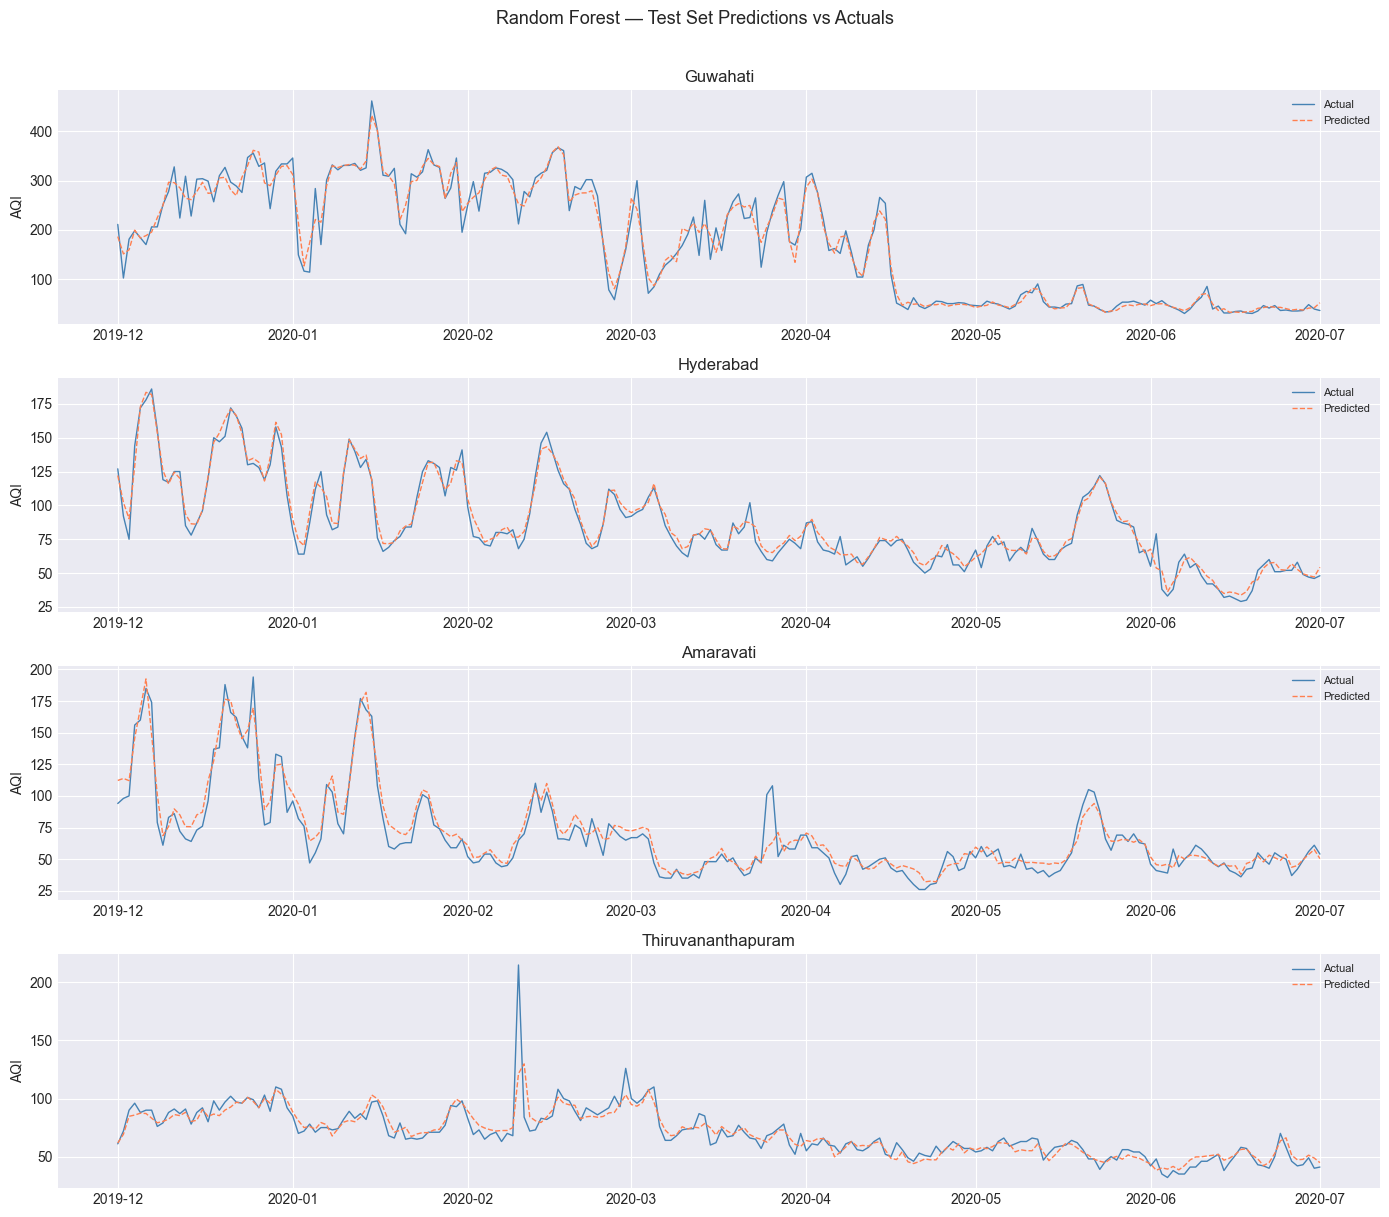

In [9]:
sample_cities = test_df['city'].value_counts().head(4).index.tolist()
ts_df = test_df[['city', 'date']].copy()
ts_df['actual'] = y_test_raw
ts_df['predicted'] = y_pred_raw_rf

fig, axes = plt.subplots(len(sample_cities), 1,
                         figsize=(14, 3 * len(sample_cities)), sharex=False)

for ax, city in zip(axes, sample_cities):
    city_data = ts_df[ts_df['city'] == city].sort_values('date')
    ax.plot(city_data['date'], city_data['actual'], label='Actual', color='steelblue', lw=1)
    ax.plot(city_data['date'], city_data['predicted'], label='Predicted', color='coral', lw=1, ls='--')
    ax.set(ylabel='AQI', title=city)
    ax.legend(loc='upper right', fontsize=8)

plt.suptitle('Random Forest — Test Set Predictions vs Actuals', y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

## Next steps

Run `comparison.ipynb` to compare Random Forest against all other models using the saved JSON metrics file.